In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df = pd.read_csv('customer_retail csv file.csv')

In [ ]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [ ]:
df = df.dropna()

In [ ]:
df = df[['Quantity','UnitPrice','Country']]

In [ ]:
encoder = LabelEncoder()
df['Country_encoded'] = encoder.fit_transform(df['Country'])

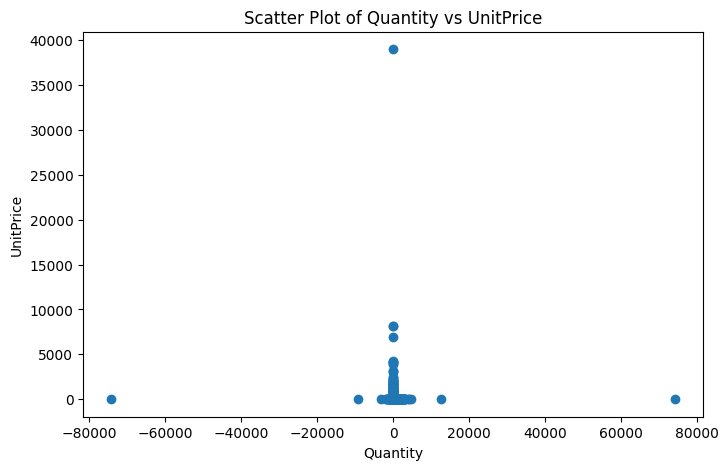

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'],df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.show()

In [ ]:
x=df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Logistic Regression:")
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
y_pred_log = log_model.predict(x_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy_log)
cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm)


print("DEcision Tree:")
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(cm)


print("KNN:")
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)
cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:")
print(cm)

Logistic Regression:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8888248125767871
Confusion Matrix:
[[    0     0     0 ...     0   231     0]
 [    0     0     0 ...     0    83     0]
 [    0     0     0 ...     0     2     0]
 ...
 [    0     0     0 ...     0    14     0]
 [   15     0     0 ...     0 70898     0]
 [    0     0     0 ...     0    40     0]]
DEcision Tree:
Accuracy: 0.890166236241005
Confusion Matrix:
[[   15     0     0 ...     0   196     0]
 [    0     0     0 ...     0    79     0]
 [    0     0     0 ...     0     2     0]
 ...
 [    0     0     0 ...     0    14     0]
 [   19     6     0 ...     0 70762     1]
 [    0     0     0 ...     0    40     0]]
KNN:
Accuracy: 0.8877215856379911
Confusion Matrix:
[[   21     0     0 ...     0   190     0]
 [    0     0     0 ...     0    79     0]
 [    0     0     0 ...     0     2     0]
 ...
 [    0     0     0 ...     0    14     0]
 [   65     0     0 ...     0 70581     0]
 [    0     0     0 ...     0    40     0]]


In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [accuracy_log, accuracy_dt, accuracy_knn]

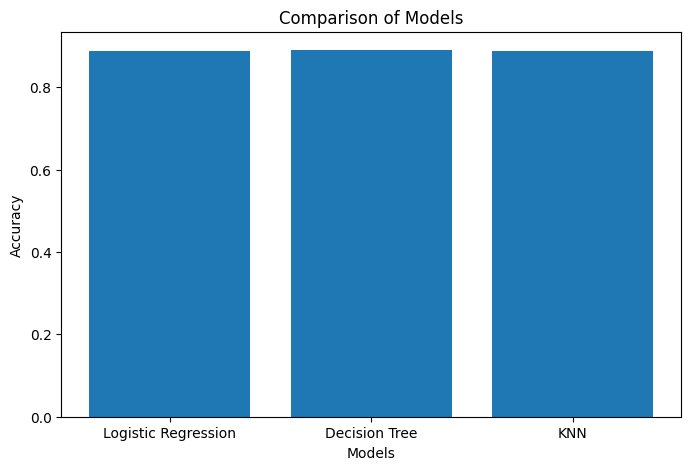

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Models')
plt.show()